In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'


In [ ]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=1, min_p=0.6)

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


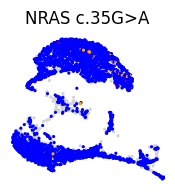

In [4]:
variant = 'NRAS c.35G>A'

adata.obs[variant + '_call'] = adata.obsm['genotype_call'][variant] 

### only look at left side of UMAP where NRAS clone shows up
fig,ax = plt.subplots(figsize=(2,2))
sc.pl.umap(adata[adata.obs['pheno_leiden'].isin([4,9,13,15,16,17])], color = variant + '_call', palette=color_palette, frameon=False, ax=ax, show=False, legend_loc=None,title = variant[0:15])

ax.set_xlim(-5,0)
plt.savefig('../plots/' + variant + '_UMAP.pdf')


In [5]:
adata.obs['clone'] = pd.read_csv('../output/clone_assignments.csv', index_col=0)['clone']

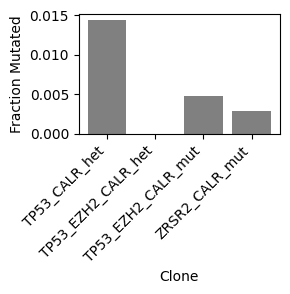

In [7]:
clones = []
fracs = []
for clone in adata.obs['clone'].unique():
    if pd.isna(clone):
        continue
    frac_mutated = 1 - adata[adata.obs['clone'] == clone].obs['NRAS c.35G>A_call'].value_counts(normalize=True)['wt']
    clones.append(clone)
    fracs.append(frac_mutated)

fig, ax = plt.subplots(figsize=(3,3))
sorted_indices = [1, 3, 0, 2]
ax.bar(range(len(clones)), [fracs[i] for i in sorted_indices], color = 'grey')
ax.set_xticks(range(len(clones)))
ax.set_xticklabels([clones[i] for i in sorted_indices])
ax.set_ylabel('Fraction Mutated')
ax.set_xlabel('Clone')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/NRAS_fraction_mutated_by_clone.pdf')
